In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from utils import N, print_decorated

Генерація псевдовипадкових чисел за формулою $z_{i+1} = (a \cdot z_i) \pmod c$ та перетворення на рівномірний розподіл $U(0, 1)$ через $x = z / c$

In [11]:
def generate_lcg_data(a, c, size):
    z = np.zeros(size)
    z[0] = 123456789 % c
    
    for i in range(size - 1):
        z[i + 1] = (a * z[i]) % c
        
    return z / c

Обчислення емпіричних та теоретичних характеристик рівномірного розподілу: середнього $E[X] = 0.5$ і дисперсії $Var[X] = \frac{1}{12}$

$$E[X]=\frac{0 + 1}{2} = 0.5$$
$$Var[X]=\frac{(1-0)^2}{12}=\frac{1}{12}$$

In [12]:
def calculate_lcg_statistics(x):
    mean_emp = np.mean(x)
    var_emp = np.var(x, ddof=1)
    mean_theor = 0.5
    var_theor = 1 / 12
    return mean_emp, var_emp, mean_theor, var_theor

Перевірка гіпотези про рівномірний закон розподілу $U(0, 1)$ за критерієм узгодженості Пірсона ($\chi^2$)

In [13]:
def perform_lcg_chi2_test(x, k_bins, N):
    counts, _ = np.histogram(x, bins=k_bins, range=(0, 1))
    expected_counts = np.full(k_bins, N / k_bins)
    
    chi2_stat = np.sum((counts - expected_counts) ** 2 / expected_counts)
    df = k_bins - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)
    
    return chi2_stat, p_value

Побудова сітки графіків (subplots) для всіх наборів параметрів ЛКМ

In [14]:
def plot_all_lcg_distributions(params, get_data_func, k_bins, N):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    
    for i, (a, c) in enumerate(params):
        x = get_data_func(a, c, N)
        
        ax = axes[i]
        ax.hist(x, bins=k_bins, range=(0, 1), density=True, alpha=0.6, color="lightgreen", edgecolor="black")
        ax.axhline(1.0, color="r", linestyle="--", label="Теор. густина U(0, 1)")
        
        ax.set_title(f"LCG (a={a}, c={c})")
        ax.set_xlabel("x")
        ax.set_ylabel("Густина")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    if len(params) < len(axes):
        fig.delaxes(axes[-1])
        
    plt.tight_layout()
    plt.show()

Головна функція для виконання другого завдання

 Лінійний конгруентний метод (Рівномірний розподіл) 

Параметри: a = 1220703125, c = 2147483648:
Середнє:  емпіричне = 0.5015, теоретичне = 0.5000
Дисперсія: емпірична = 0.0832, теоретична = 0.0833
Хі-квадрат: stat = 7.8240, p-value = 0.5520
Гіпотеза про рівномірний розподіл U(0, 1) ПРИЙМАЄТЬСЯ

Параметри: a = 1664525, c = 4294967296:
Середнє:  емпіричне = 0.4992, теоретичне = 0.5000
Дисперсія: емпірична = 0.0830, теоретична = 0.0833
Хі-квадрат: stat = 5.1720, p-value = 0.8191
Гіпотеза про рівномірний розподіл U(0, 1) ПРИЙМАЄТЬСЯ

Параметри: a = 3, c = 7:
Середнє:  емпіричне = 0.5000, теоретичне = 0.5000
Дисперсія: емпірична = 0.0595, теоретична = 0.0833
Хі-квадрат: stat = 6666.6680, p-value = 0.0000
Гіпотеза ВІДХИЛЯЄТЬСЯ (погано підібрані параметри a, c)

Параметри: a = 200, c = 118:
Середнє:  емпіричне = 0.5000, теоретичне = 0.5000
Дисперсія: емпірична = 0.0805, теоретична = 0.0833
Хі-квадрат: stat = 46.9300, p-value = 0.0000
Гіпотеза ВІДХИЛЯЄТЬСЯ (погано підібрані параметри a, c)


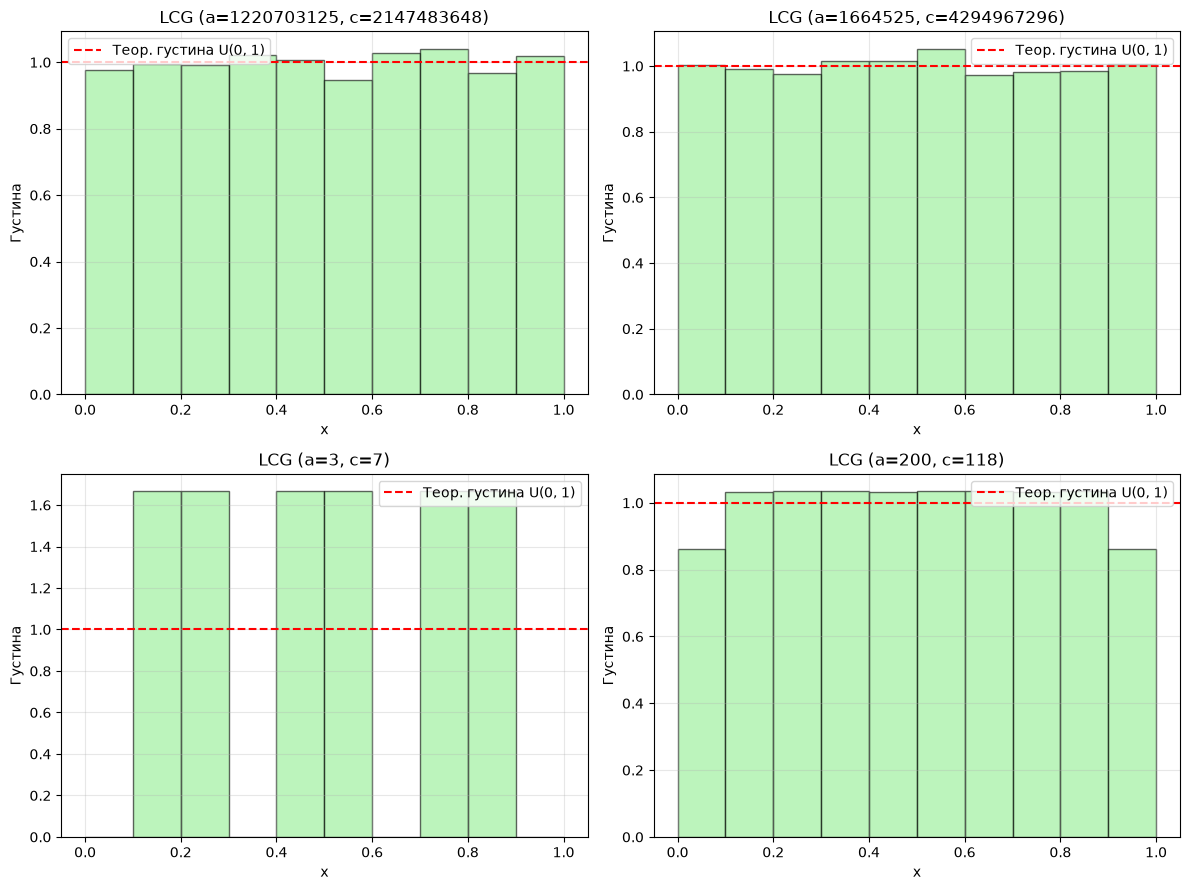

In [16]:
def task_2_lcg(params=[(5**13, 2**31), (1664525, 2**32), (3, 7), (200, 118)], k_bins=10, alpha=0.05):
    print_decorated("Лінійний конгруентний метод (Рівномірний розподіл)", True)

    for a, c in params:
        x = generate_lcg_data(a, c, N)
        mean_emp, var_emp, mean_theor, var_theor = calculate_lcg_statistics(x)
        
        print(f"\nПараметри: a = {a}, c = {c}:")
        print(f"Середнє:  емпіричне = {mean_emp:.4f}, теоретичне = {mean_theor:.4f}")
        print(f"Дисперсія: емпірична = {var_emp:.4f}, теоретична = {var_theor:.4f}")

        chi2_stat, p_value = perform_lcg_chi2_test(x, k_bins, N)
        
        print(f"Хі-квадрат: stat = {chi2_stat:.4f}, p-value = {p_value:.4f}")
        if p_value > alpha:
            print("Гіпотеза про рівномірний розподіл U(0, 1) ПРИЙМАЄТЬСЯ")
        else:
            print("Гіпотеза ВІДХИЛЯЄТЬСЯ (погано підібрані параметри a, c)")

    plot_all_lcg_distributions(params, generate_lcg_data, k_bins, N)

if __name__ == "__main__":
    task_2_lcg()

a і c впливають на якість генерації розподілення. Якщо значення маленькі, то швидко починають утворюватись повторення значень і паттерни, відповідно в таких випадках гіпотеза про рівномірний розподіл не справджується